In [3]:
!pip install numpy matplotlib scikit-fuzzy
!pip install scypy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.2 MB/s eta 0:00:00


 RESULTADOS DOS TESTES - SISTEMA FUZZY DA IA

[Cenário 1: Jogador Quase Morto e Perto]
 -> Entradas  : Vida = 10%, Distância = 2.0m
 -> Saída IA  : Agressividade = 64.91%
 -> Esperado  : Agressividade Frenética (> 70%)

[Cenário 2: Jogador Forte e Longe]
 -> Entradas  : Vida = 90%, Distância = 18.0m
 -> Saída IA  : Agressividade = 36.57%
 -> Esperado  : Agressividade Passiva (< 25%)

[Cenário 3: Combate Equilibrado]
 -> Entradas  : Vida = 50%, Distância = 10.0m
 -> Saída IA  : Agressividade = 64.32%
 -> Esperado  : Agressividade Cautelosa (~ 50%)

[Cenário 4: Jogador Forte no Melee (Perto)]
 -> Entradas  : Vida = 85%, Distância = 4.0m
 -> Saída IA  : Agressividade = 64.79%
 -> Esperado  : Agressividade Moderada/Alta (~ 60%)


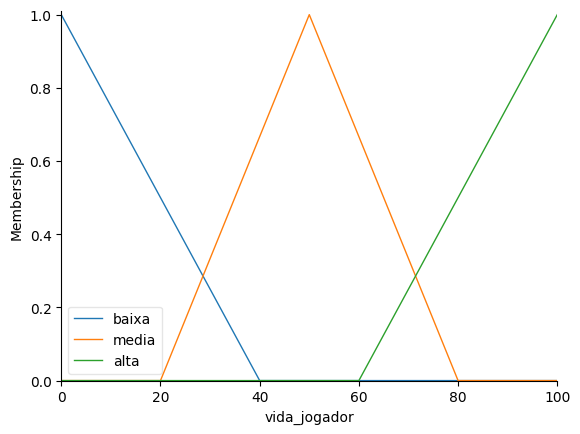

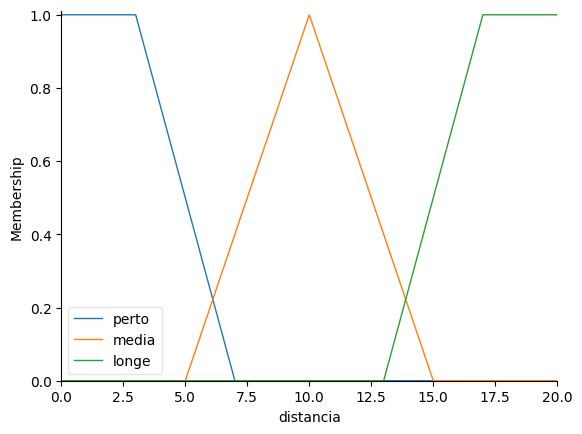

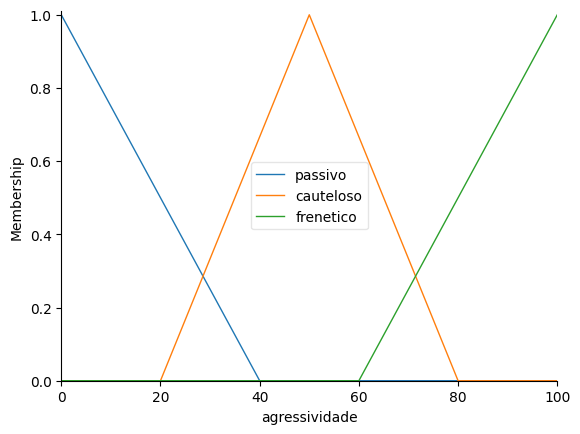

In [5]:
"""
SISTEMA DE INFERÊNCIA FUZZY: Agressividade de Inimigo em Jogos
Requisitos:
  pip install numpy matplotlib scikit-fuzzy
"""

import matplotlib.pyplot as plt
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# 1. Definindo as variáveis e Universos de Discurso
vida_jogador = ctrl.Antecedent(np.arange(0, 101, 1), "vida_jogador")
distancia = ctrl.Antecedent(np.arange(0, 20.1, 0.1), "distancia")
agressividade = ctrl.Consequent(
    np.arange(0, 101, 1), "agressividade", defuzzify_method="centroid"
)

# 2. Definindo as Funções de Pertinência
# Vida do Jogador (%)
vida_jogador["baixa"] = fuzz.trimf(vida_jogador.universe, [0, 0, 40])
vida_jogador["media"] = fuzz.trimf(vida_jogador.universe, [20, 50, 80])
vida_jogador["alta"] = fuzz.trimf(vida_jogador.universe, [60, 100, 100])

# Distância (metros)
distancia["perto"] = fuzz.trapmf(distancia.universe, [0, 0, 3, 7])
distancia["media"] = fuzz.trimf(distancia.universe, [5, 10, 15])
distancia["longe"] = fuzz.trapmf(distancia.universe, [13, 17, 20, 20])

# Agressividade do Inimigo (%)
agressividade["passivo"] = fuzz.trimf(agressividade.universe, [0, 0, 40])
agressividade["cauteloso"] = fuzz.trimf(agressividade.universe, [20, 50, 80])
agressividade["frenetico"] = fuzz.trimf(agressividade.universe, [60, 100, 100])

# 3. Base de Regras (mínimo 6 regras, usando E [&] e OU [|])
regras = [
    ctrl.Rule(
        distancia["perto"] & vida_jogador["baixa"], agressividade["frenetico"]
    ),
    ctrl.Rule(
        distancia["perto"] & vida_jogador["alta"], agressividade["cauteloso"]
    ),
    ctrl.Rule(
        distancia["longe"] | vida_jogador["baixa"], agressividade["cauteloso"]
    ),
    ctrl.Rule(
        distancia["longe"] & vida_jogador["alta"], agressividade["passivo"]
    ),
    ctrl.Rule(
        distancia["media"] & vida_jogador["media"], agressividade["cauteloso"]
    ),
    ctrl.Rule(
        distancia["perto"] | vida_jogador["media"], agressividade["frenetico"]
    ),
    ctrl.Rule(
        distancia["media"] & vida_jogador["baixa"], agressividade["frenetico"]
    ),
    ctrl.Rule(
        distancia["media"] & vida_jogador["alta"], agressividade["passivo"]
    ),
    ctrl.Rule(
        distancia["longe"] & vida_jogador["media"], agressividade["passivo"]
    ),
]

# 4. Criando o Sistema de Controle
sistema_controle = ctrl.ControlSystem(regras)
ia_inimigo = ctrl.ControlSystemSimulation(sistema_controle)


# Função auxiliar para rodar simulações
def avaliar_inimigo(vida, dist):
  ia_inimigo.input["vida_jogador"] = vida
  ia_inimigo.input["distancia"] = dist
  ia_inimigo.compute()
  return ia_inimigo.output["agressividade"]


# ---------- Bateria de Testes ----------
cenarios = [
    {
        "nome": "Cenário 1: Jogador Quase Morto e Perto",
        "vida": 10,
        "dist": 2.0,
        "esperado": "Agressividade Frenética (> 70%)",
    },
    {
        "nome": "Cenário 2: Jogador Forte e Longe",
        "vida": 90,
        "dist": 18.0,
        "esperado": "Agressividade Passiva (< 25%)",
    },
    {
        "nome": "Cenário 3: Combate Equilibrado",
        "vida": 50,
        "dist": 10.0,
        "esperado": "Agressividade Cautelosa (~ 50%)",
    },
    {
        "nome": "Cenário 4: Jogador Forte no Melee (Perto)",
        "vida": 85,
        "dist": 4.0,
        "esperado": "Agressividade Moderada/Alta (~ 60%)",
    },
]

print("=" * 60)
print(" RESULTADOS DOS TESTES - SISTEMA FUZZY DA IA")
print("=" * 60)

for c in cenarios:
  out = avaliar_inimigo(c["vida"], c["dist"])
  print(f"\n[{c['nome']}]")
  print(f" -> Entradas  : Vida = {c['vida']}%, Distância = {c['dist']}m")
  print(f" -> Saída IA  : Agressividade = {out:.2f}%")
  print(f" -> Esperado  : {c['esperado']}")

# ---------- Gráficos das Funções de Pertinência ----------
vida_jogador.view()
distancia.view()
agressividade.view()
plt.show()